# 4o Lab de PSD (notebook para preencher com os resultados)

### Número do Grupo : 5

In [ ]:
#
# Primeiro vamos importar as bibliotecas necessárias
#
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, correlate

## Definição do par de transformadas DFT - (direta e inversa)   

O par de transformadas discretas de Fourier (Discrete Fourier Transform - DFT) para um sinal de tempo discreto $x[n]$ com índice das amostras igual $n$ e o correspondente espectro de Fourier $X[k]$ com índice de frequências $k$ é calculado como  
\begin{align}
    \text{DFT}: X[k]=&\sum_{n=0}^{N-1}x[n]\cdot\mathrm{e}^{-\mathrm{j}\frac{2\pi}{N}nk}\\
    \text{IDFT}: x[n]=&\frac{1}{N}\sum_{k=0}^{N-1}X[k]\cdot\mathrm{e}^{\mathrm{j}\frac{2\pi}{N}nk}
\end{align}

O par de transformada acima pode também ser escrito como:

\begin{align}
    \text{DFT}: X[k]=&\sum_{n=0}^{N-1}x[n]\cdot W_{N}^{nk}\\
    \text{IDFT}: x[n]=&\frac{1}{N}\sum_{k=0}^{N-1}X[k]\cdot W_{N}^{-nk}
\end{align}

\begin{align}
    \text{Twiddle Factor}: W_{N} = \mathrm{e}^{-\mathrm{j}\frac{2\pi}{N}}
\end{align}

Observe o sinal negativo na função exponential da transformada direta (DFT) e o fator de normalização $1/N$ na transformada inversa (IDFT). Essa convensão é usada pela maioria dos livros textos de DSP e também pela biblioteca Python `numpy.fft.fft()`, `numpy.fft.ifft()` e funções do Matlab `fft()`, `ifft()`.

# PROBLEMA 1

## DFT e IDFT com "loops for"

Agora vamos implementar a DFT e a IDFT usando "loops for". Embora isso possa ser útil para entender e validar algoritmos em sua fase inicial de desenvolvimento, tal implementação deve ser evitada para um uso prático: "loops for" normalmente são lentos e muitas vezes mais complicados de ler do que implementações usando matrizes e vetores. Especialmente para $N$ muito grandes, o tempo de computação é muito longo.

De qualquer forma, o conceito de "loop for" é: a DFT pode ser implementada com um "loop for" externo iterando sobre $k$ e um "loop for" interno somando todos os $n$ para um $k$ específico.

Usamos variável com subscrito _ aqui, a fim de salvar bons nomes de variáveis para o cálculo baseado em matriz.

## Parte A

Escreva as funções DFT e IDFT que calculam, respectivamente, as transformadas discretas de Fourier direta e inversa.

In [ ]:
#
# Função para calcular a DFT (com loops for) de um sinal de valor complexo (dtype=complex)
#
# Entrada: x -> vetor contendo as amostras (números complexos) do sinal no tempo
# Saída: X -> vetor contendo os coeficientes espectrais (números complexos) - (dtype=complex)
#
# Vai precisar de 2 loops
def DFT_1D(x):
    # -> INSIRA SEU CÓDIGO AQUI !!
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range (0, N):
      a = 0
      for n in range (0, N):
        a += x[n] * np.exp(-1j * ((2 * np.pi) / N) * n * k)
      X[k] = a
    return X

vetor = np.array([1 + 2j, 2 - 1j, 0 + 1j, -1 - 1j])
novo_vetor = DFT_1D(vetor)
novo_vetor = np.round(novo_vetor, decimals=5)
print(f'Vetor resultado: {novo_vetor}')

vetor_esperado = np.fft.fft(vetor)
print(f'Vetor esperado: {vetor_esperado}')

Vetor resultado: [ 2.+1.j  1.-2.j -0.+5.j  1.+4.j]
Vetor esperado: [2.+1.j 1.-2.j 0.+5.j 1.+4.j]


In [ ]:
#
# Função para calcular a IDFT (com loops for) de um sinal de valor complexo (dtype=complex)
#
# Entrada: X -> vetor contendo os coeficientes espectrais (números complexos)
# Saída: x -> vetor contendo as amostras (números complexos) do sinal no tempo
#
def IDFT_1D(X):
    # -> INSIRA SEU CÓDIGO AQUI !!
    # -> INSIRA SEU CÓDIGO AQUI !!
    N = len(X)
    x = np.zeros(N, dtype=complex)
    a = 0
    for k in range (0, N):
      a = 0
      for n in range (0, N):
        a += X[n] * np.exp(1j * ((2 * np.pi) / N) * n * k)
      x[k] = 1/N * a
    return x

vetor = np.array([1 + 2j, 2 - 1j, 0 + 1j, -1 - 1j])
novo_vetor = IDFT_1D(vetor)
novo_vetor = np.round(novo_vetor, decimals=5)
print(f'Vetor resultado: {novo_vetor}')

vetor_esperado = np.fft.ifft(vetor)
print(f'Vetor esperado: {vetor_esperado}')

Vetor resultado: [0.5 +0.25j 0.25+1.j   0.  +1.25j 0.25-0.5j ]
Vetor esperado: [0.5 +0.25j 0.25+1.j   0.  +1.25j 0.25-0.5j ]


## Parte B

Estude o código abaixo que cria uma sinal discreto composto pela soma de três ondas senoides com amplitude e frequências distintas.

[ 0.00000000e+00  6.49951092e-01  1.24301000e+00  1.73098263e+00
  2.08154121e+00  2.28261600e+00  2.34327722e+00  2.29102039e+00
  2.16602580e+00  2.01350931e+00  1.87561275e+00  1.78433917e+00
  1.75681059e+00  1.79365925e+00  1.88074856e+00  1.99377423e+00
  2.10474409e+00  2.18898123e+00  2.23120727e+00  2.22945607e+00
  2.19600566e+00  2.15511222e+00  2.13796970e+00  2.17587843e+00
  2.29297677e+00  2.50000000e+00  2.79035655e+00  3.13938578e+00
  3.50706391e+00  3.84376807e+00  4.09811869e+00  4.22550953e+00
  4.19578177e+00  3.99863534e+00  3.64577057e+00  3.16934473e+00
  2.61699766e+00  2.04432572e+00  1.50614412e+00  1.04809007e+00
  7.00042246e-01  4.72482828e-01  3.56371693e-01  3.26445884e-01
  3.47223767e-01  3.80502964e-01  3.92885361e-01  3.61888418e-01
  2.79502648e-01  1.52571317e-01  3.06161700e-16 -1.52571317e-01
 -2.79502648e-01 -3.61888418e-01 -3.92885361e-01 -3.80502964e-01
 -3.47223767e-01 -3.26445884e-01 -3.56371693e-01 -4.72482828e-01
 -7.00042246e-01 -1.04809

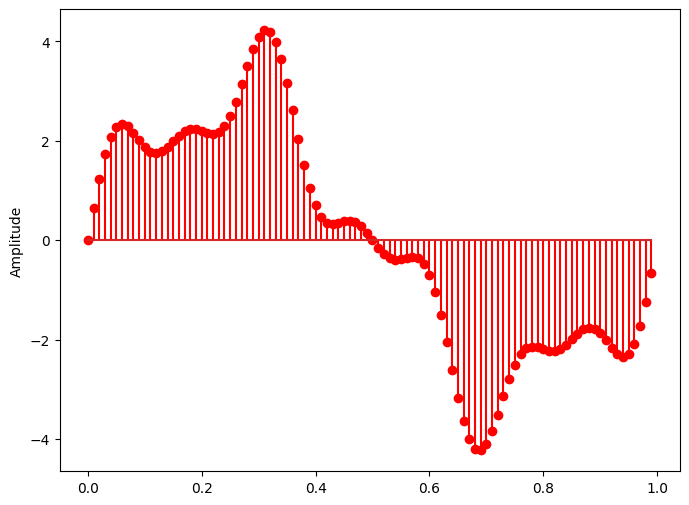

In [ ]:
# taxa de amostragem (sampling rate)
sr = 100

# intervalo de amostragem
ts = 1.0/sr
t = np.arange(0,1,ts)

xprob1 = 2

freq = 1.
xprob1 = 3*np.sin(2*np.pi*freq*t)

freq = 4
xprob1 += np.sin(2*np.pi*freq*t)

freq = 7
xprob1 += 0.5*np.sin(2*np.pi*freq*t)

print(xprob1)

plt.figure(figsize = (8, 6))
plt.stem(t, xprob1, linefmt='red')
plt.ylabel('Amplitude')

plt.show()

## Parte C

Escreva um código que utilize a função DFT criada anteriormente para calcular e plotar o espectro de frequências, abs($X$), do sinal $x$ criado acima.

**OBS**: Observe que a DFT codificada recebe como entrada um sinal complexo e o sinal acima é do tipo real. Portanto, transforme o sinal $x$ em uma sequência complexa com a parte imaginária igual a zero.

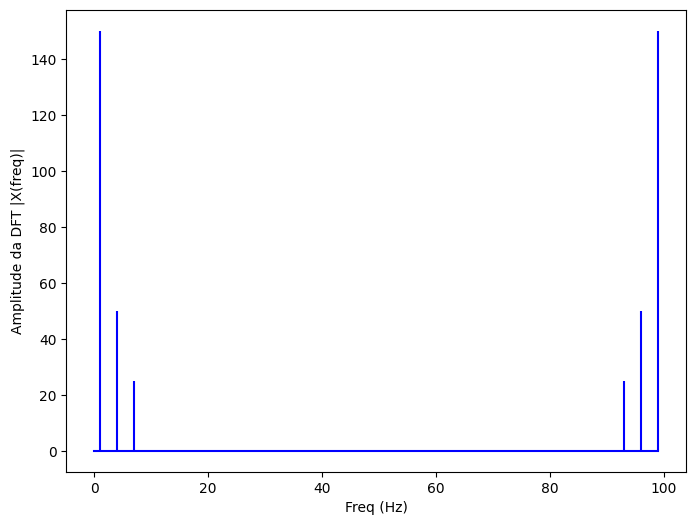

In [ ]:
# tamanho do vetor
N = len(xprob1)

# cria um vetor de números complexos
# -> INSIRA SEU CÓDIGO AQUI !!
x_complex = xprob1.astype(complex)

# chamada à função DFT
# -> INSIRA SEU CÓDIGO AQUI !!
X = DFT_1D(x_complex)

# calcula a frequência
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (8, 6))
plt.stem(freq, abs(X), linefmt='blue', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude da DFT |X(freq)|')
plt.show()

No gráfico acima é possível notar que a saída da DFT é simétrica na metade da taxa de amostragem (você pode tentar uma taxa de amostragem diferente para testar).

Essa metade da taxa de amostragem é chamada de **frequência de Nyquist**, em homenagem ao engenheiro eletrônico **Harry Nyquist**. Harry Nyquist e Claude Shannon criaram o famoso teorema de amostragem de **Nyquist-Shannon**, que afirma que um sinal amostrado a uma taxa $f_s$ pode ser totalmente reconstruído se contiver apenas componentes de frequência abaixo da metade dessa frequência de amostragem, ou seja, a taxa de amostragem deve ser maior que duas vezes a máxima frequência do sinal, $f_s > f_{max}$.

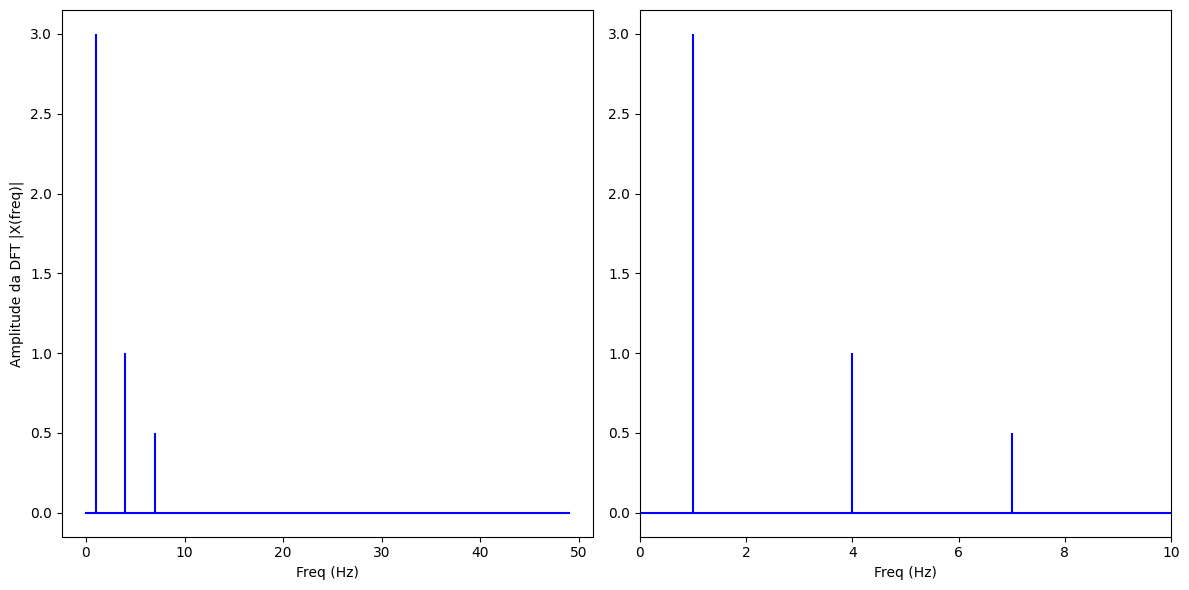

In [ ]:
n_oneside = N//2

# obtem as frequências de um lado
f_oneside = freq[:n_oneside]

# normaliza a amplitude do sinal
X_oneside = X[:n_oneside]/n_oneside

plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.stem(f_oneside, abs(X_oneside), linefmt='blue', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude da DFT |X(freq)|')

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), linefmt='blue', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')

# Limita o eixo x até frequência de 10 Hz
plt.xlim(0, 10)

plt.tight_layout()
plt.show()

## Limitações da DFT implementada

O principal problema com a implementação da DFT acima é que ela não é eficiente se tivermos um sinal com muitas amostras. Nesse caso, o cálculo da DFT pode levar muito tempo.

## Parte D

Escreva uma função em python que implemente o sinal indicado abaixo.

\begin{equation}
f(t) = 3sin(2\pi f t),
\end{equation}

sendo $f=2$ Hz

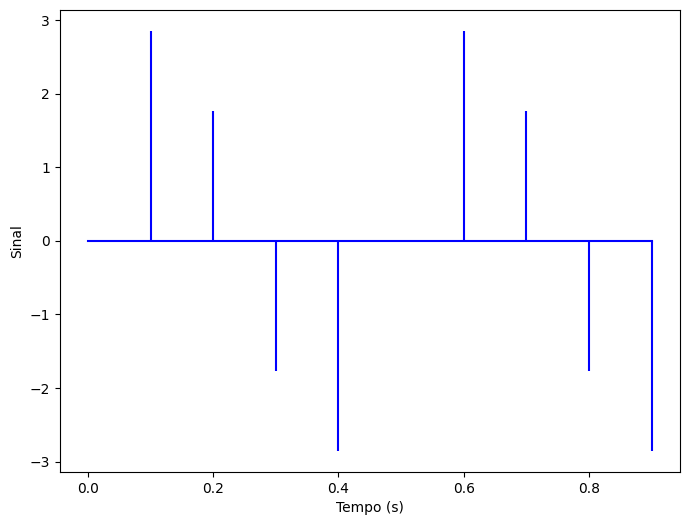

In [ ]:
#
# sr = taxa de amostragem
#


def sinal(sr):

    ts = 1.0/sr
    t = np.arange(0,1,ts)

    freq = 2.

    # -> INSIRA SEU CÓDIGO AQUI !!

    func = 3 * np.sin(2*np.pi*freq*t)

    return func

sinal_ = sinal(10)
ts = 1.0/10
t = np.arange(0,1,ts)

plt.figure(figsize = (8, 6))
plt.stem(t, sinal_, linefmt='blue', markerfmt=" ", basefmt="-b")
plt.xlabel('Tempo (s)')
plt.ylabel('Sinal')
plt.show()

## Parte E

Escreva um simples programa em python que varia a taxa de amostragem (sr) do sinal acima de 500 e 1000, com passo de 100 e, para cada uma das taxas, determine a DFT do sinal gerado e imprima o tempo de execução.

**OBS** Use o código abaixo como exemplo de como medir o tempo de execução

In [ ]:
import time
start_time = time.time()
#
# código para medir o tempo vai aqui
#
print("--- %s seconds ---" % (time.time() - start_time))

--- 4.76837158203125e-05 seconds ---


In [ ]:
import time

start = 500
stop  = 1000
step  = 100

# -> INSIRA SEU CÓDIGO AQUI !!
sr = np.arange(start, stop, step)
tam = len(sr)

for c in sr:
  start_time = time.time()
  sinal_desejado = sinal(c)
  vetor = sinal_desejado.astype(complex)

  novo_sinal = DFT_1D(vetor)
  # N = len(novo_sinal)
  # freq = np.arange(N) * c / N

  print(f'O tempo de execução de {c}: {time.time() - start_time}')

  # plt.figure(figsize = (8, 6))
  # plt.stem(freq, abs(novo_sinal), linefmt='blue', markerfmt=" ", basefmt="-b")
  # plt.xlabel('Taxa de amostragem')
  # plt.ylabel('DFT do sinal gerado')
  # plt.show()

O tempo de execução de 500: 0.37746310234069824
O tempo de execução de 600: 0.5805721282958984
O tempo de execução de 700: 0.7500996589660645
O tempo de execução de 800: 1.505789041519165
O tempo de execução de 900: 1.9846742153167725


## Parte F

Agora, utilize a função IDFT_1D para obter e plotar o sinal original $x$ criado na "parte A" a partir do seu espetro $X$ obtido na "parte C"

**OBS**: Observe que a IDFT_1D codificada recebe como entrada um sinal complexo e retorna um sinal complexo. Portanto, para obter o sinal $x$ criado na "parte B", você precisa utilizar apenas a parte real do sinal de retorno.

Text(0, 0.5, 'Amplitude')

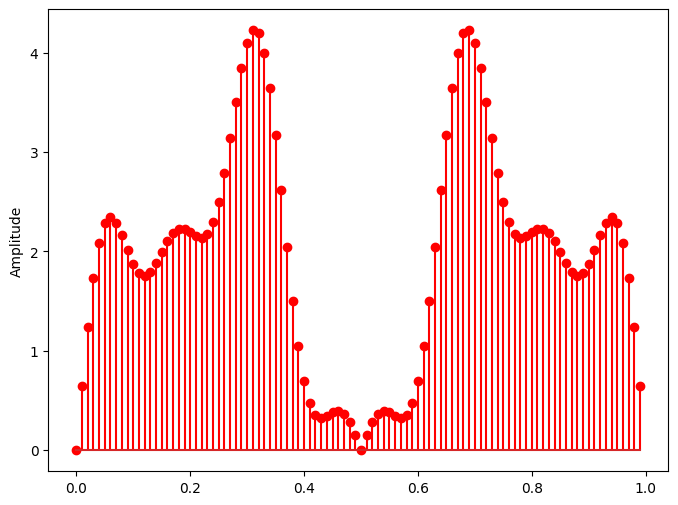

In [ ]:
# -> INSIRA SEU CÓDIGO AQUI !!
x = IDFT_1D(X)
real_x = abs(x)

sr = 100
ts = 1.0/sr
t = np.arange(0,1,ts)

plt.figure(figsize = (8, 6))
plt.stem(t, real_x, linefmt='red')
plt.ylabel('Amplitude')

# PROBLEMA 2

## Parte A

Estenda para sinais 2D (imagens) os códigos da DFT e IDFT implementados anteriormente para sinais 1D

**DICA**: Use do fato que a 2D-DFT pode ser escrita a partir da 1D-DFT, como indicado abaixo


\begin{equation}
F(u,v) = \frac{1}{MN} \sum_{x=0}^{N} \sum_{y=0}^{M} f(x,y) e^{-j 2\pi \left( \frac{ux}{N} + \frac{vy}{M} \right)} = \frac{1}{M} \sum_{y=0}^{M} \left[ \frac{1}{N} \sum_{x=0}^{N} f(x,y)\ e^{-j 2\pi \frac{ux}{N}} \right]  e^{-j 2\pi \frac{vy}{M}}
\end{equation}

In [ ]:
#
# Função para calcular a DFT (com loops for) de um sinal de valor complexo (dtype=complex)
#
# Entrada: x -> vetor contendo as amostras (números complexos) do sinal no tempo
# Saída: X -> vetor contendo os coeficientes espectrais (números complexos) - (dtype=complex)
#
def DFT_2D(x):
    # -> INSIRA SEU CÓDIGO AQUI !!
    rows, cols = x.shape

    aux = np.zeros(x.shape, dtype=complex)

    # Para cada linha, fazer DFT, fazer transposta, depois fazer DFT de cada linha novamente, depois fazer outra transposta
    for i in range(0, rows):
      aux[i] = DFT_1D(x[i])

    aux = np.transpose(aux)

    for j in range(0, cols):
      aux[j] = DFT_1D(aux[j])

    aux = np.transpose(aux)

    return aux

# Teste
linhas, colunas = 4, 5

parte_real = np.random.randn(linhas, colunas)
parte_imaginaria = np.random.randn(linhas, colunas)

matriz_complexa = parte_real + 1j * parte_imaginaria

resultado = DFT_2D(matriz_complexa)
print(f'Resultado:\n {resultado}')

valor_esperado = np.fft.fft2(matriz_complexa)
print(f'\nValor esperado:\n {valor_esperado}')

Resultado:
 [[ 3.09284265 +0.9948702j   2.61507852 +2.16740966j
  -3.18685465 -1.87202694j  7.76460421+10.95892421j
  -5.86433307 +3.34275232j]
 [ 7.70999465 +4.67950675j  5.17368958 -1.13619552j
   1.70156364 +3.05679229j  7.92264687 +5.15282906j
  -0.28953463 -1.22841965j]
 [-3.73098988 +2.7454659j  -0.92590845 +6.16914911j
   1.29904292 -6.17020811j  1.85058591 -1.9875013j
   2.95323567 +3.19158596j]
 [-0.70620656 +3.81575479j  1.98456938 -0.09510847j
   8.20981886 -3.00535513j  3.07189399 -2.33540131j
  -0.74253731 +0.7888652j ]]

Valor esperado:
 [[ 3.09284265 +0.9948702j   2.61507852 +2.16740966j
  -3.18685465 -1.87202694j  7.76460421+10.95892421j
  -5.86433307 +3.34275232j]
 [ 7.70999465 +4.67950675j  5.17368958 -1.13619552j
   1.70156364 +3.05679229j  7.92264687 +5.15282906j
  -0.28953463 -1.22841965j]
 [-3.73098988 +2.7454659j  -0.92590845 +6.16914911j
   1.29904292 -6.17020811j  1.85058591 -1.9875013j
   2.95323567 +3.19158596j]
 [-0.70620656 +3.81575479j  1.98456938 -0.09510

In [ ]:
#
# Função para calcular a IDFT (com loops for) de um sinal de valor complexo (dtype=complex)
#
# Entrada: X -> vetor contendo os coeficientes espectrais (números complexos)
# Saída: x -> vetor contendo as amostras (números complexos) do sinal no tempo
#
def IDFT_2D(X):
    # -> INSIRA SEU CÓDIGO AQUI !!
    rows, cols = X.shape

    aux = np.zeros(X.shape, dtype=complex)

    # Para cada linha, fazer DFT, fazer transposta, depois fazer DFT de cada linha novamente, depois fazer outra transposta
    for i in range(0, rows):
      aux[i] = IDFT_1D(X[i])

    aux = np.transpose(aux)

    for j in range(0, cols):
      aux[j] = IDFT_1D(aux[j])

    aux = np.transpose(aux)

    return aux

resultado = IDFT_2D(matriz_complexa)
print(f'Resultado:\n {resultado}')

valor_esperado = np.fft.ifft2(matriz_complexa)
print(f'\nValor esperado:\n {valor_esperado}')

Resultado:
 [[ 0.15464213+0.04974351j -0.29321665+0.16713762j  0.38823021+0.54794621j
  -0.15934273-0.09360135j  0.13075393+0.10837048j]
 [-0.03531033+0.19078774j -0.03712687+0.03944326j  0.1535947 -0.11677007j
   0.41049094-0.15026776j  0.09922847-0.00475542j]
 [-0.18654949+0.1372733j   0.14766178+0.1595793j   0.0925293 -0.09937506j
   0.06495215-0.30851041j -0.04629542+0.30845746j]
 [ 0.38549973+0.23397534j -0.01447673-0.06142098j  0.39613234+0.25764145j
   0.08507818+0.15283961j  0.25868448-0.05680978j]]

Valor esperado:
 [[ 0.15464213+0.04974351j -0.29321665+0.16713762j  0.38823021+0.54794621j
  -0.15934273-0.09360135j  0.13075393+0.10837048j]
 [-0.03531033+0.19078774j -0.03712687+0.03944326j  0.1535947 -0.11677007j
   0.41049094-0.15026776j  0.09922847-0.00475542j]
 [-0.18654949+0.1372733j   0.14766178+0.1595793j   0.0925293 -0.09937506j
   0.06495215-0.30851041j -0.04629542+0.30845746j]
 [ 0.38549973+0.23397534j -0.01447673-0.06142098j  0.39613234+0.25764145j
   0.08507818+0.1528

## Parte B

Escreva um código simples que leia a imagem fornecida para essa prática, calcule a sua DFT e plote o espectro de Fourier.

**OBS**: Use a função do opencv para a leitura e visualização da imagem e do seu espetro.

**DICA de USO - Leitura e Escrita de uma imagem**

im_gray = cv2.imread('Nome_da_Imagem', cv2.IMREAD_GRAYSCALE)

cv2.imwrite('Nome_da_Imagem', im_gray)

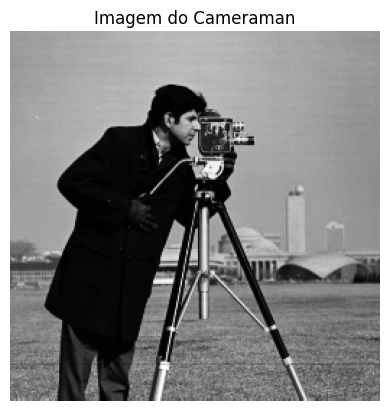

In [ ]:
import cv2
import matplotlib.pyplot as plt

# -> INSIRA SEU CÓDIGO AQUI !!
im_gray = cv2.imread("cameraman.tiff", cv2.IMREAD_GRAYSCALE)
cv2.imwrite('cameraman.tiff', im_gray)
resultado = DFT_2D(im_gray)

plt.imshow(im_gray, 'gray')
plt.title("Imagem do Cameraman")
plt.axis('off')
plt.show()

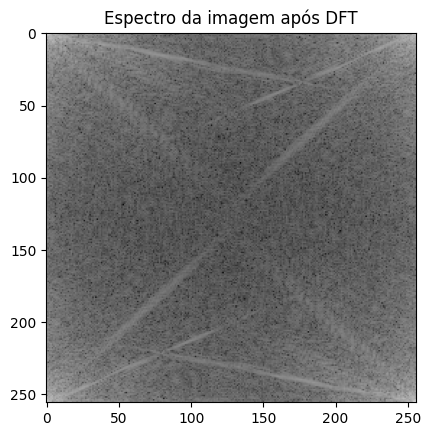

In [ ]:
plt.imshow(np.log(abs(resultado)), 'gray')
plt.title("Espectro da imagem após DFT")
plt.show()

# PROBLEMA 3

## Parte A - Representação matricial da DFT - (transformada direta)

Como vimos em sala de aula, a DFT pode ser escrita na forma matricial como indicado abaixo.

\begin{equation}
    \textrm{DFT : } \quad F_{k} = \sum_{n=0}^{N-1}x_n\cdot e^{-\frac{j2\pi kn}{N}} =  \sum_{n=0}^{N-1}x_n\cdot (W_{N})^{kn}, \quad k=0,1,\ldots,N-1  \nonumber
\end{equation}

sendo $W_N = e^{-\frac{j2\pi}{N}}$ o núcleo da transformada.

\begin{equation}
		\begin{bmatrix}
			F_{0} \\ F_{1} \\ F_{2} \\ \vdots \\ F_{N-1}
		\end{bmatrix}
		=
		\begin{bmatrix}
			1      & 1           & 1              & \dots  & 1               \\
			1      & W_{N}       & W_{N}^2        & \dots  & W_{N}^{N-1}     \\
			1      & W_{N}^{2}   & W_{N}^4        & \dots  & W_{N}^{2(N-1)}  \\
			\vdots & \vdots      & \vdots         & \ddots & \vdots          \\
			1      & W_{N}^{N-1} & W_{N}^{2(N-1)} & \dots  & W_{N}^{(N-1)^2}
		\end{bmatrix}
		\begin{bmatrix}
			x_0 \\ x_1  \\ x_2 \\ \vdots \\ x_{N-1}
		\end{bmatrix} \nonumber
\end{equation}

Escreva um código que implemente a matrix da DFT como indicada acima.

**DICA**: Estude a função meshgrid do numpy. Crie um meshgrid de tamanho $N \times N$ e utilize os seus índices para gerar a matrix $W$

In [ ]:
#
# Entrada: N -> tamanho da matrix DFT
# Saída: W -> matrix DFT
#
def DFT_matrix(N):

  x = np.linspace(0, N-1, N)
  y = np.linspace(0, N-1, N)

  X, Y = np.meshgrid(x, y)
  exp = np.array(X * Y, dtype=complex)

  w = np.exp(-1j*2*np.pi/N)
  w = np.power(w, exp)

  return np.round(w, 2)

print(f'Verificando:\n {DFT_matrix(5)}')

Verificando:
 [[ 1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j  ]
 [ 1.  +0.j    0.31-0.95j -0.81-0.59j -0.81+0.59j  0.31+0.95j]
 [ 1.  +0.j   -0.81-0.59j  0.31+0.95j  0.31-0.95j -0.81+0.59j]
 [ 1.  +0.j   -0.81+0.59j  0.31-0.95j  0.31+0.95j -0.81-0.59j]
 [ 1.  +0.j    0.31+0.95j -0.81+0.59j -0.81-0.59j  0.31-0.95j]]


Utilizando a matriz DFT gerada acima, encontre o espectro de Fourier do sinal gerado no PROBLEMA 1 - Parte B e compare o resultado com o resultado obtido no PROBLEMA 1 - Parte C.

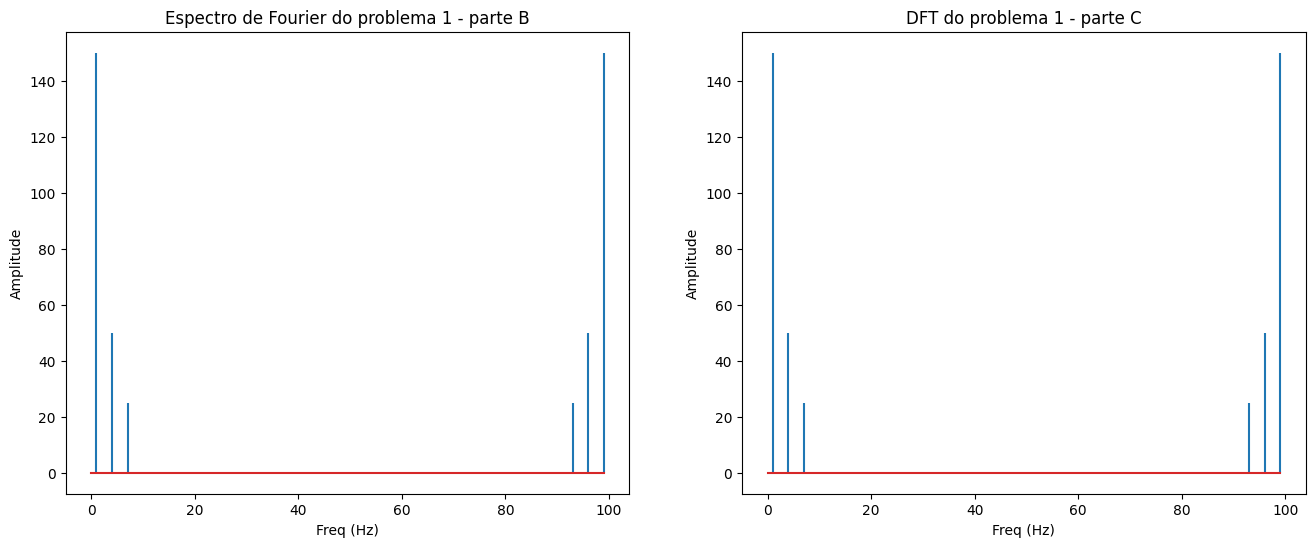

In [ ]:
# -> INSERIR SEU CÓDIGO AQUI !
W = np.dot(DFT_matrix(len(xprob1)), xprob1)

# Calculando a frequência
n = np.arange(len(xprob1))
T = N/sr
freq = n/T

plt.figure(figsize = (16, 6))
plt.subplot(1, 2, 1)
plt.stem(freq, abs(DFT_1D(xprob1)), markerfmt=" ")
plt.title("Espectro de Fourier do problema 1 - parte B")
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude')

plt.subplot(1, 2, 2)
plt.stem(freq, abs(W), markerfmt=" ")
plt.title("DFT do problema 1 - parte C")
plt.xlabel('Freq (Hz)')
plt.ylabel('Amplitude')
plt.show()

plt.show()

## Parte B - Representação matricial da iDFT - (transformada inversa)

Como vimos em sala de aula, a iDFT pode ser escrita na forma matricial como indicado abaixo.

\begin{equation}
    \textrm{iDFT : } \quad x_{n} = \frac{1}{N}\sum_{K=0}^{N-1}F_k\cdot e^{\frac{j2\pi kn}{N}}, \quad n=0,1,\ldots,N-1  \nonumber
\end{equation}

\begin{equation}
    \begin{bmatrix}
        x_{0} \\ x_{1} \\ x_{2} \\ \vdots \\ x_{N-1}
    \end{bmatrix}
    = \frac{1}{N}
    \begin{bmatrix}
        1      & 1              & 1               & \dots  & 1               \\
        1      & W_{N}^{-1}     & W_{N}^{-2}      & \dots  & W_{N}^{-(N-1)}     \\
        1      & W_{N}^{-2}     & W_{N}^{-4}      & \dots  & W_{N}^{-2(N-1)}  \\
        \vdots & \vdots         & \vdots          & \ddots & \vdots          \\
        1      & W_{N}^{-(N-1)} & W_{N}^{-2(N-1)} & \dots  & W_{N}^{-(N-1)^2}
        \end{bmatrix}
        \begin{bmatrix}
        F_0 \\ F_1  \\ F_2 \\ \vdots \\ F_{N-1}
    \end{bmatrix} \nonumber
\end{equation}

Escreva um código que implemente a matrix da iDFT como indicada acima e plot o sinal gerado. Verifique se o sinal é igual ao sinal original usado como entrada na parte A desse problema.

In [ ]:
#
# Entrada: N -> tamanho da matrix DFT
# Saída: W -> matrix DFT
#
def iDFT_matrix(N):

  x = np.linspace(0, N-1, N)
  y = np.linspace(0, N-1, N)

  X, Y = np.meshgrid(x, y)
  exp = np.array(X * Y, dtype=complex) # Define k*n

  w = np.exp(1j*2*np.pi/N)
  w = np.power(w, exp)
  w = 1/N * w

  return np.round(w, 2)

print(f'Verificando:\n {iDFT_matrix(5)}')

Verificando:
 [[ 0.2 +0.j    0.2 +0.j    0.2 +0.j    0.2 +0.j    0.2 +0.j  ]
 [ 0.2 +0.j    0.06+0.19j -0.16+0.12j -0.16-0.12j  0.06-0.19j]
 [ 0.2 +0.j   -0.16+0.12j  0.06-0.19j  0.06+0.19j -0.16-0.12j]
 [ 0.2 +0.j   -0.16-0.12j  0.06+0.19j  0.06-0.19j -0.16+0.12j]
 [ 0.2 +0.j    0.06-0.19j -0.16-0.12j -0.16+0.12j  0.06+0.19j]]


## Parte C - caso 2D

Pense em como usar as matrizes DFTs 1D implementadas anteriormente para o caso de imagens (sinal 2D)

In [ ]:
# Muito provavelmente bastaria utilizar a função DFT de 1 dimensão
def DFT2D_matrix(N, M):

  DFT_matrix_rows = DFT_matrix(N)
  DFT_matrix_cols = DFT_matrix(M)

  return np.dot(DFT_matrix_rows, DFT_matrix_cols)

  DFT2D_matrix(5, 5)

# PROBLEMA 4

Como vimos na teoria, a convolução de dois sinais no domínio do tempo/espaço é realizada na frequência como a multiplicação das transformadas de Fourier dos respectivos sinais.

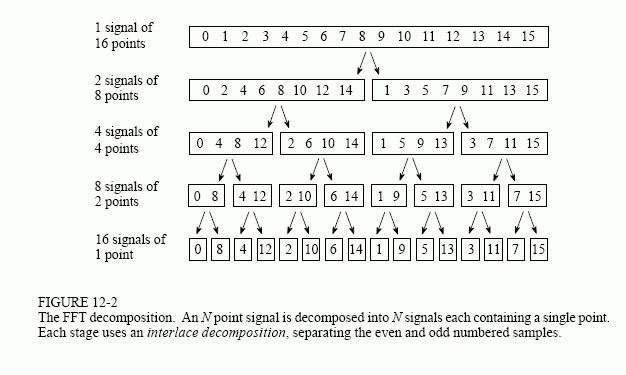

## Parte A - implementação dos passos 1 a 3

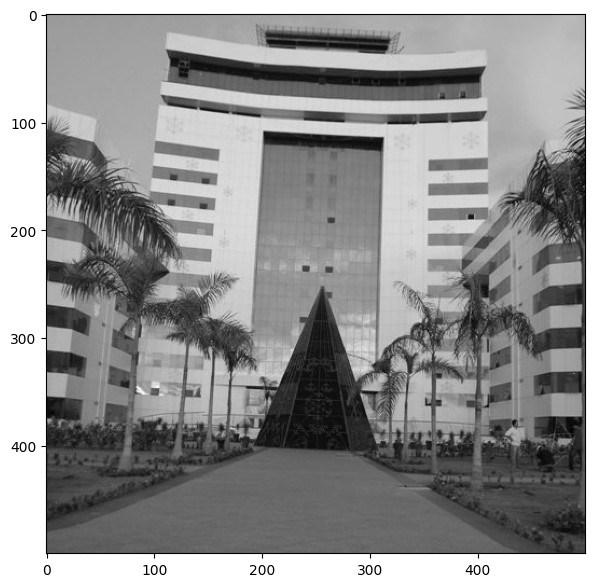

In [ ]:
# Leitura de imagem
img = cv2.imread('predio.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=[7,7])
plt.imshow(img, cmap='gray')
plt.show()

In [ ]:
def zero_padding(f, ps_rows, ps_cols):
    len_row_f, len_col_f = f.shape

    a = ps_rows // 2
    b = ps_cols // 2

    f_padded = np.zeros((len_row_f + ps_rows, len_col_f + ps_cols))

    f_padded[a : a + len_row_f, b : b + len_col_f] = f

    return f_padded

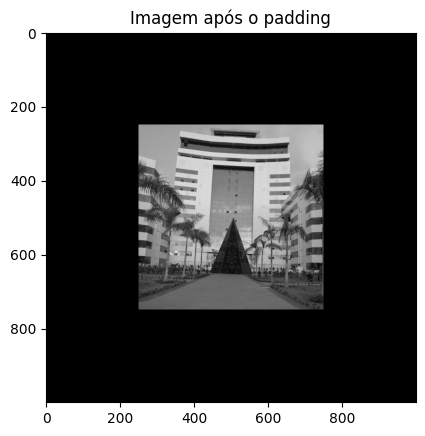

In [ ]:
#
# Step 1 - Padding da imagem
#

row, col = img.shape
img_padded_first = zero_padding(img, row, col)

plt.title("Imagem após o padding")
plt.imshow(img_padded_first, cmap='gray')
plt.show()

#
# Step 2 - Multiplicao da imagem após padding por (-1)^(x+y)
#

exp = np.power(-1, sum(np.meshgrid(range(img_padded_first.shape[0]), range(img_padded_first.shape[1]))))
img_padded = img_padded_first * exp

#
# Step 3 - Converter imagem do domínio do espaço para o domínio da frequência
#
# OBS: Nesse passo, utilize a função np.fft.fft2() do numpy
#

img_dom_freq = np.fft.fft2(img_padded)

**OBS1**: Lembre que a transformada de fourier gera um conjunto de $k$ números complexos

$F_k = R_k + j*I_k$

e, portanto, podemos calcular a magnitude e fase como:


$|F_k| = \sqrt{R_k^2 + I_k^2}$


$\phi_k = \arctan\left( \frac{I_k}{R_k} \right)$


**OBS2**: Lembre que, para melhor visualização do espectro de Fourier, é importante alterar a faixa dinâmica da magnitude dos coeficientes, como:

$c*log(1+|F_k|)$

sendo $c$ uma constante para escalonamento. Use $c=30$ para melhor visualização.

Crie um subplot (plt.subplot()) que mostre a magnitude (antes e depois o escalonamento indicado acima) e a fase do espectro.  

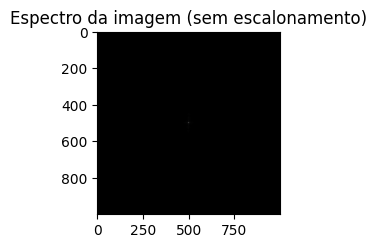

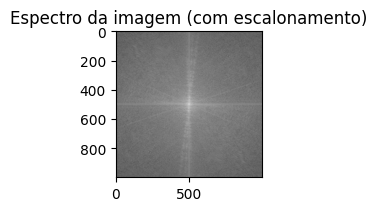

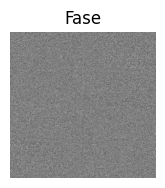

In [ ]:
plt.figure(figsize=[8, 6.])

magn = abs(img_dom_freq)
phase = np.angle(img_dom_freq, deg=True)

# Magnitude antes do escalonamento
plt.subplot(1, 3, 1)
plt.title("Espectro da imagem (sem escalonamento)")
plt.imshow(magn, 'gray')
plt.show()

# Magnitudee depois do escalonamento
plt.subplot(1, 3, 2)
plt.imshow(30 * np.log(1 + magn), 'gray')
plt.title("Espectro da imagem (com escalonamento)")
plt.show()

plt.subplot(1, 3, 3)
plt.imshow(phase, 'gray')
plt.title("Fase")
plt.axis('off')
plt.show()

Crie um subplot (plt.subplot()) que mostre a magnitude escalonada do espectro **com e sem** a execução do Step 2. Estude os resultados.

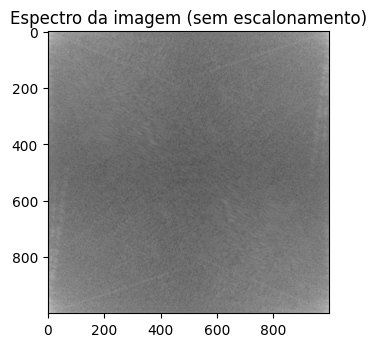

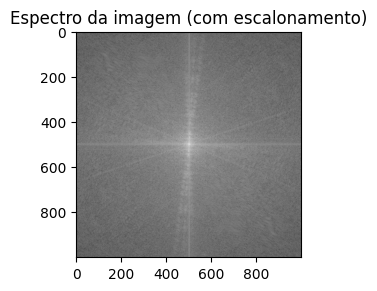

In [ ]:
plt.figure(figsize=[8, 6.])

# Sem step 2
magn1 = abs(np.fft.fft2(img_padded_first))

# Magnitude com escalonamento
plt.subplot(1, 2, 1)
plt.title("Espectro da imagem (sem escalonamento)")
plt.imshow(30 * np.log(1 + magn1), 'gray')
plt.show()

# Com step 2

# Magnitudee depois do escalonamento
plt.subplot(1, 2, 2)
plt.imshow(30 * np.log(1 + magn), 'gray')
plt.title("Espectro da imagem (com escalonamento)")
plt.show()

## Parte B - implementação do passo 4

In [ ]:
#
# Step 4 - geração de um filtro passa-baixa (de tamanho PxQ) no domínio da frequência
#
def ideal_low_pass_filter(img, radius):
    '''Cria um filtro passa-baixa de mesma dimensão que img.
       radius define o raio do filtro, isto é, a máxima frequência que será mantida na imagem'''

    num_rows, num_cols = img.shape
    freq_r = np.fft.fftfreq(num_rows)
    freq_c = np.fft.fftfreq(num_cols)
    freq_r = np.fft.fftshift(freq_r)
    freq_c = np.fft.fftshift(freq_c)

    low_pass_filter = np.zeros([num_rows, num_cols])
    for row in range(num_rows):
        for col in range(num_cols):
            distance = np.sqrt(freq_r[row]**2 + freq_c[col]**2)
            if distance <= radius:
                low_pass_filter[row, col] = 1

    return low_pass_filter

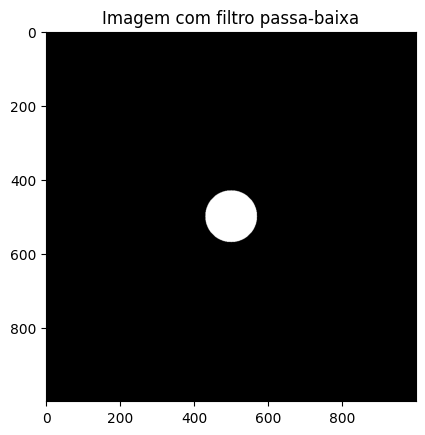

In [ ]:
#
# Crie e mostre (plt.imshow) um filtro usando o código acima com radius = 0.07
#
# -> INSIRA O SEU CÓDIGO AQUI !
img_filtered = ideal_low_pass_filter(img_dom_freq, 0.07)
plt.title("Imagem com filtro passa-baixa")
plt.imshow(img_filtered, cmap='gray')
plt.show()

## Parte C - implementação do passo 5

Implemente abaixo a seguinte equação: $G(\mu, v) = H(\mu, v) \cdot F(\mu, v) $

In [ ]:
# -> INSERIR SEU CÓDIGO AQUI !!
# Fazendo a convolução no domínio da freq e multiplicação as matrizes
G_dom_freq = img_filtered * img_dom_freq

## Parte D - implementação do passo 6

Implemente um código que faça a conversão da imagem do domínio da frequência para o domínio do espaço.

Plot o resultado obtido.

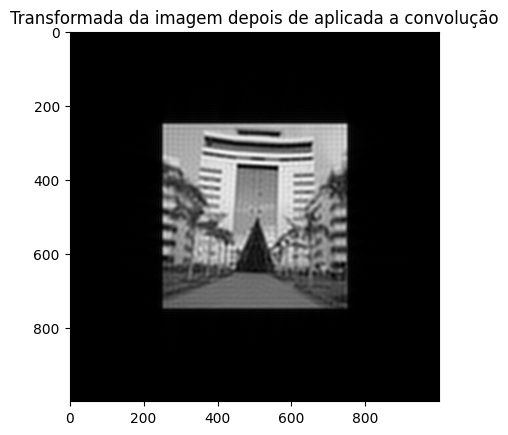

In [ ]:
# -> INSERIR SEU CÓDIGO AQUI !!
G_dom_esp = np.fft.ifft2(G_dom_freq)
plt.title("Transformada da imagem depois de aplicada a convolução")
plt.imshow(abs(G_dom_esp), cmap='gray')
plt.show()

## Parte E - implementação do passo 7

Implemente um código para extrair a região $M \times N$ do quadrante superior esquerda da imagem resultante do passo 6.

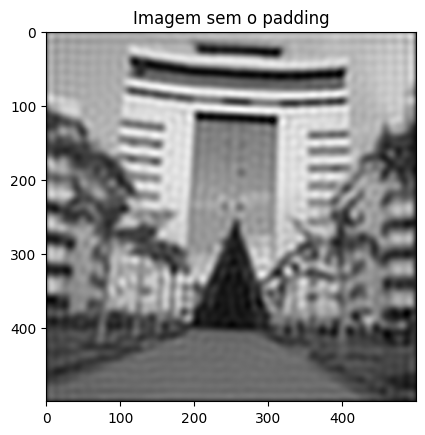

In [ ]:
# -> INSERIR SEU CÓDIGO AQUI !!
img_extr = abs(G_dom_esp[250:750, 250:750])

plt.title("Imagem sem o padding")
plt.imshow(img_extr, cmap='gray')
plt.show()

## Parte F - implementação de um filtro passa baixa Gaussiano

Modifique o código do passo 4 para criar um filro passa baixa Gaussiano. O filtro Gaussian 2D no domínio da frequência é definido por $G(u,v) = e^{-D^2(u,v)/2D_o^2}$, sendo $D_o$ uma constante positiva e $D(u, v)$ a distância entre um ponto $(u, v)$ no domínio de frequência e o centro do retângulo de frequência.

Usando esse novo filtro execute novamente os passos 5, 6 e 7 e analise os resultados obtidos usando os dois filtros (passa-baixas ideal e passa-baixas Gaussiano).



In [ ]:
# -> INSERIR SEU CÓDIGO AQUI !!
# Definindo o novo filtro
def gauss_ideal_low_pass_filter(img, radius):
    '''Cria um filtro passa-baixa de mesma dimensão que img.
       radius define o raio do filtro, isto é, a máxima frequência que será mantida na imagem'''

    num_rows, num_cols = img.shape
    freq_r = np.fft.fftfreq(num_rows)
    freq_c = np.fft.fftfreq(num_cols)
    freq_r = np.fft.fftshift(freq_r)
    freq_c = np.fft.fftshift(freq_c)

    low_pass_filter = np.zeros([num_rows, num_cols])
    for row in range(num_rows):
        for col in range(num_cols):
            distance = np.sqrt(freq_r[row]**2 + freq_c[col]**2)
            low_pass_filter[row, col] = np.exp(-(distance**2) / (2 * 0.01 **2))
            sigma = radius


    return low_pass_filter

In [ ]:
# Passo 5 - Convolução no domínio da frequência e multiplicação das matrizes
new_img_filtered = gauss_ideal_low_pass_filter(img_dom_freq, 0.07)
new_G_dom_freq = new_img_filtered * img_dom_freq

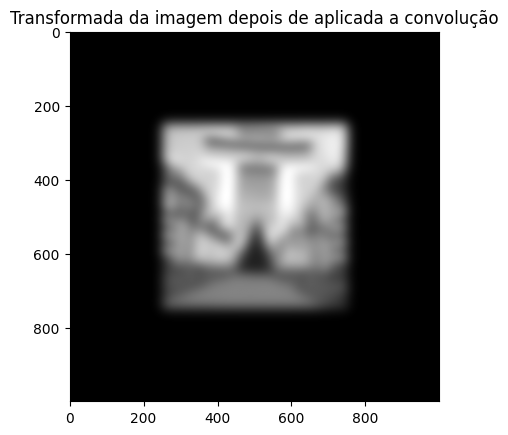

In [ ]:
# Passo 6 - Conversão da imagem do domínio da frequência para o domínio do espaço
new_G_dom_esp = np.fft.ifft2(new_G_dom_freq)
plt.title("Transformada da imagem depois de aplicada a convolução")
plt.imshow(abs(new_G_dom_esp), cmap='gray')
plt.show()

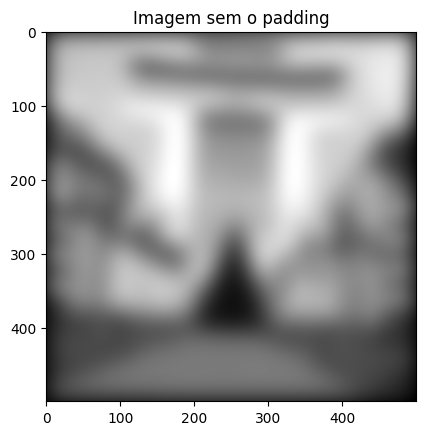

In [ ]:
# Passo 7 - Extrair a região de interesse da imagem
new_img_extr = abs(new_G_dom_esp[250:750, 250:750])

plt.title("Imagem sem o padding")
plt.imshow(new_img_extr, cmap='gray')
plt.show()

# That's All Folks

Oii professor! Corrija com carinho =)


Assinado: Carolina e Nicole :D